In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3375 entries, 0 to 3374
Data columns (total 58 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_flat_adj                    3375 non-null   int64  
 1   floor_count                    3375 non-null   int64  
 2   features_house                 655 non-null    object 
 3   features_yard                  797 non-null    object 
 4   parking_desc                   1233 non-null   object 
 5   address                        3375 non-null   object 
 6   address_city_category_id       1977 non-null   float64
 7   address_city_microcategory_id  1977 non-null   float64
 8   address_city_verical           1977 non-null   object 
 9   lat                            3375 non-null   float64
 10  lon                            3375 non-null   float64
 11  description                    3375 non-null   object 
 12  area                           3375 non-null   f

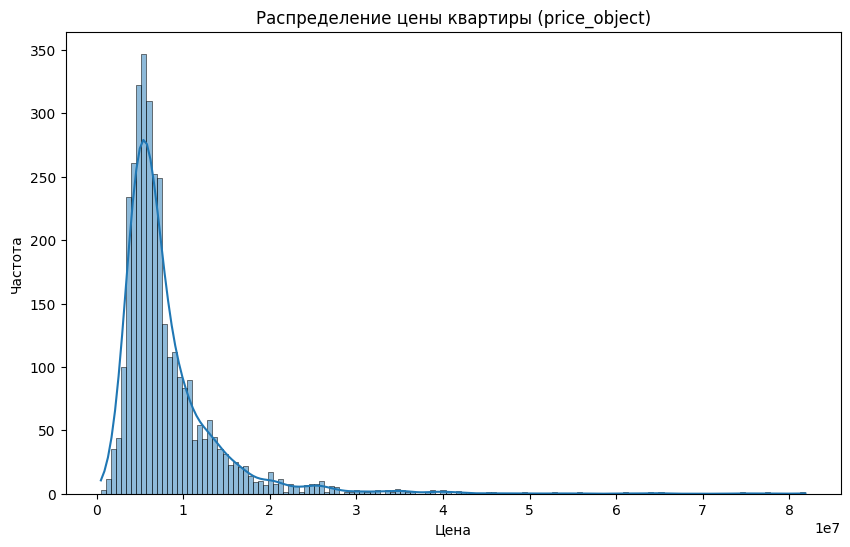

(None,
    id_flat_adj  floor_count features_house  \
 0   1058534920           12   Мусоропровод   
 1   1061363753           18       Консьерж   
 2   1103958872            5            Газ   
 3   1183832737            9            NaN   
 4   1211651942           10            NaN   
 
                            features_yard  \
 0                       Детская площадка   
 1  Детская площадка, Спортивная площадка   
 2  Детская площадка, Спортивная площадка   
 3                                    NaN   
 4  Детская площадка, Спортивная площадка   
 
                                  parking_desc  \
 0                           Открытая во дворе   
 1  Наземная многоуровневая, Открытая во дворе   
 2                           Открытая во дворе   
 3                                         NaN   
 4                                         NaN   
 
                                              address  \
 0  Нижегородская обл., Нижний Новгород, ул. Аркад...   
 1  Нижегородская обл

In [2]:
# Загрузка данных
data = pd.read_csv(r'C:\Users\ekart\VKRS_DS\flat_data.csv')

# Основная информация о данных
data_info = data.info()

# Первые несколько строк данных
data_head = data.head()

# Статистическое описание числовых признаков
data_description = data.describe()

# Распределение целевой переменной (price_object)
plt.figure(figsize=(10, 6))
sns.histplot(data['price_object'], kde=True)
plt.title('Распределение цены квартиры (price_object)')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

data_info, data_head, data_description

In [7]:
data['price_object'].isnull().sum()

0

# если в будущем будут появлятся новые признаки то целевую переменную ничем не заполнять 

In [8]:
# Функция для удаления выбросов за 3 стандартных отклонения
def remove_outliers_std(df, column):
    mean = df[column].mean()
    std_dev = df[column].std()
    upper_bound = mean + 3 * std_dev
    lower_bound = mean - 3 * std_dev
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [9]:
# Удалим столбцы с более чем 50% пропусков
threshold = len(data) * 0.5
data_cleaned = data.dropna(thresh=threshold, axis=1)

In [10]:
# Заполним пропуски в числовых признаках средним или медианой
for column in data_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    if data_cleaned[column].isnull().sum() > 0:
        data_cleaned[column].fillna(data_cleaned[column].median(), inplace=True)

C:\Users\ekart\AppData\Local\Temp\ipykernel_2408\1794126301.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[column].fillna(data_cleaned[column].median(), inplace=True)
C:\Users\ekart\AppData\Local\Temp\ipykernel_2408\1794126301.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[column].fillna(data_cleaned[column].median(), inplace=True)
C:\Users\ekart\AppData\Local\Temp\ipykernel_2408\1794126301.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

In [11]:
# Заполним пропуски в категориальных признаках модой
for column in data_cleaned.select_dtypes(include=['object']).columns:
    if data_cleaned[column].isnull().sum() > 0:
        data_cleaned[column].fillna(data_cleaned[column].mode()[0], inplace=True)

C:\Users\ekart\AppData\Local\Temp\ipykernel_2408\1958965930.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[column].fillna(data_cleaned[column].mode()[0], inplace=True)
C:\Users\ekart\AppData\Local\Temp\ipykernel_2408\1958965930.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[column].fillna(data_cleaned[column].mode()[0], inplace=True)
C:\Users\ekart\AppData\Local\Temp\ipykernel_2408\1958965930.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

In [12]:
# Удаление выбросов для каждого числового признака по 3 стандартным отклонениям
for feature in data_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    data_cleaned = remove_outliers_std(data_cleaned, feature)

In [13]:
# Проверка формы данных после удаления выбросов
data_cleaned.shape


(2846, 36)

C:\Users\ekart\AppData\Local\Temp\ipykernel_2408\3787576150.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = data_cleaned.corr()


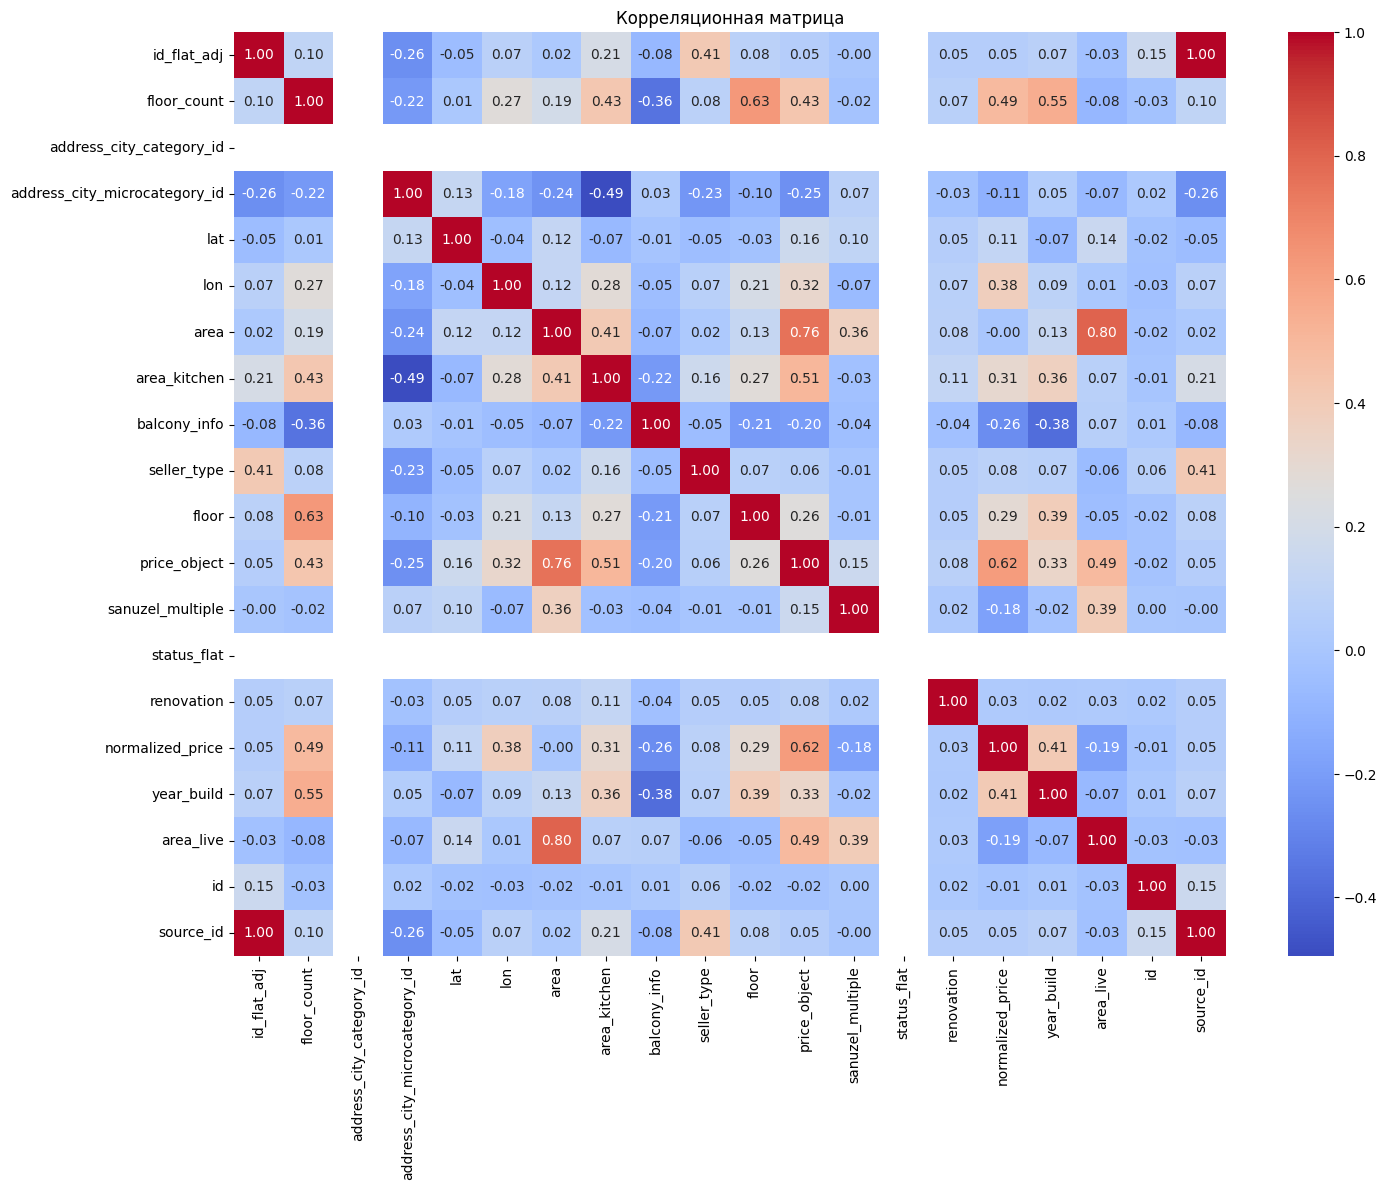

In [14]:
# Шаг 4: Проверка данных на мультиколлинеарность и избавление от нее

# Построим корреляционную матрицу
corr_matrix = data_cleaned.corr()

# Выведем корреляционную матрицу
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()


In [15]:
# Шаг 4: Проверка данных на мультиколлинеарность с использованием корреляционного порога

def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Удаление сильно коррелированных признаков с порогом 0.9
data_cleaned_no_multicollinearity, dropped_features = remove_highly_correlated_features(data_cleaned.drop(columns=['price_object']))

# Добавим обратно целевую переменную
data_cleaned_no_multicollinearity['price_object'] = data_cleaned['price_object']

# Проверка формы данных и оставшихся признаков
data_cleaned_no_multicollinearity_shape = data_cleaned_no_multicollinearity.shape
remaining_features = data_cleaned_no_multicollinearity.columns

data_cleaned_no_multicollinearity_shape, dropped_features, remaining_features


C:\Users\ekart\AppData\Local\Temp\ipykernel_2408\132962113.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df.corr().abs()


((2846, 35),
 ['source_id'],
 Index(['id_flat_adj', 'floor_count', 'address', 'address_city_category_id',
        'address_city_microcategory_id', 'address_city_verical', 'lat', 'lon',
        'description', 'area', 'area_kitchen', 'balcony_info', 'seller_type',
        'floor', 'house_type', 'rooms_count', 'sanuzel_multiple', 'status_flat',
        'type_flat', 'geo_around', 'renovation', 'selling_type',
        'normalized_price', 'postfix_seller', 'profile_type_seller',
        'source_name', 'city', 'year_build', 'passage_elevator', 'area_live',
        'windows_type', 'id', 'parsed_at', 'updated_at', 'price_object'],
       dtype='object'))

In [15]:
# Понизим порог до 0.8
# Удаление сильно коррелированных признаков с порогом 0.8
data_cleaned_no_multicollinearity, dropped_features = remove_highly_correlated_features(data_cleaned.drop(columns=['price_object']), threshold=0.8)

# Добавим обратно целевую переменную
data_cleaned_no_multicollinearity['price_object'] = data_cleaned['price_object']

# Проверка формы данных и оставшихся признаков
data_cleaned_no_multicollinearity_shape = data_cleaned_no_multicollinearity.shape
remaining_features = data_cleaned_no_multicollinearity.columns

data_cleaned_no_multicollinearity_shape, dropped_features, remaining_features


C:\Users\ekart\AppData\Local\Temp\ipykernel_9412\132962113.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df.corr().abs()


((2846, 34),
 ['area_live', 'source_id'],
 Index(['id_flat_adj', 'floor_count', 'address', 'address_city_category_id',
        'address_city_microcategory_id', 'address_city_verical', 'lat', 'lon',
        'description', 'area', 'area_kitchen', 'balcony_info', 'seller_type',
        'floor', 'house_type', 'rooms_count', 'sanuzel_multiple', 'status_flat',
        'type_flat', 'geo_around', 'renovation', 'selling_type',
        'normalized_price', 'postfix_seller', 'profile_type_seller',
        'source_name', 'city', 'year_build', 'passage_elevator', 'windows_type',
        'id', 'parsed_at', 'updated_at', 'price_object'],
       dtype='object'))

In [17]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.preprocessing import LabelEncoder

# Кодирование категориальных признаков
data_encoded = data_cleaned_no_multicollinearity.copy()
for column in data_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data_encoded[column] = le.fit_transform(data_encoded[column])

# Выделение целевой переменной и признаков
X = data_encoded.drop(columns=['price_object'])
y = data_encoded['price_object']

# Используем SelectKBest для выбора лучших числовых признаков на основе F-статистики и взаимной информации
k = 10  # количество лучших признаков
selector_f = SelectKBest(score_func=f_regression, k=k)
selector_mi = SelectKBest(score_func=mutual_info_regression, k=k)

X_new_f = selector_f.fit_transform(X, y)
X_new_mi = selector_mi.fit_transform(X, y)

selected_features_f = X.columns[selector_f.get_support()]
selected_features_mi = X.columns[selector_mi.get_support()]

selected_features_f, selected_features_mi


(Index(['floor_count', 'address_city_microcategory_id', 'lat', 'lon', 'area',
        'area_kitchen', 'balcony_info', 'floor', 'normalized_price',
        'year_build'],
       dtype='object'),
 Index(['floor_count', 'address_city_microcategory_id', 'lat', 'lon', 'area',
        'area_kitchen', 'floor', 'rooms_count', 'normalized_price',
        'year_build'],
       dtype='object'))

### Результаты:
#### На основе F-статистики:

* floor_count
* address_city_microcategory_id
* lat
* lon
* area
* area_kitchen
* balcony_info
* floor
* normalized_price
* year_build

#### На основе взаимной информации:

* floor_count
* address_city_microcategory_id
* lat
* lon
* area
* area_kitchen
* floor
* rooms_count
* normalized_price
* year_build

**Признак normalized_price следует удалить из набора данных, так как он может плохо повлиять на прогноз** 

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Исключаем признак normalized_price из отобранных признаков
selected_features_f = selected_features_f.drop('normalized_price')
selected_features_mi = selected_features_mi.drop('normalized_price')

# Объединяем отобранные признаки
selected_features = list(set(selected_features_f).union(set(selected_features_mi)))

# Обработка данных: нормализация и кодирование категориальных признаков
numeric_features = [col for col in selected_features if data_encoded[col].dtype in ['float64', 'int64']]
categorical_features = [col for col in selected_features if data_encoded[col].dtype == 'object']

# Определение препроцессора
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Разделение данных на тренировочный и тестовый наборы
X = data_encoded[selected_features]
y = data_encoded['price_object']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание пайплайна
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Применение пайплайна к тренировочным и тестовым данным
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

X_train_processed.shape, X_test_processed.shape


((2276, 9), (570, 9))

In [23]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error, r2_score

# Создание и настройка моделей
linear_model = LinearRegression()
ridge_model = Ridge()
lasso_model = Lasso()

# Полиномиальная регрессия
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train_processed)
X_test_poly = poly.transform(X_test_processed)

# Грид для поиска параметров
param_grid = {
    'ridge': {'alpha': [0.1, 1, 10, 100]},
    'lasso': {'alpha': [0.1, 1, 10, 100]}
}

# Настройка GridSearchCV для моделей с регуляризацией
ridge_cv = GridSearchCV(ridge_model, param_grid['ridge'], cv=5)
lasso_cv = GridSearchCV(lasso_model, param_grid['lasso'], cv=5)

# Обучение моделей
linear_model.fit(X_train_processed, y_train)
ridge_cv.fit(X_train_processed, y_train)
lasso_cv.fit(X_train_processed, y_train)

# Полиномиальная регрессия без регуляризации
poly_linear_model = LinearRegression()
poly_linear_model.fit(X_train_poly, y_train)

# Полиномиальная регрессия с регуляризацией (Ridge)
poly_ridge_model = Ridge()
poly_ridge_cv = GridSearchCV(poly_ridge_model, param_grid['ridge'], cv=5)
poly_ridge_cv.fit(X_train_poly, y_train)

# Полиномиальная регрессия с регуляризацией (Lasso)
poly_lasso_model = Lasso()
poly_lasso_cv = GridSearchCV(poly_lasso_model, param_grid['lasso'], cv=5)
poly_lasso_cv.fit(X_train_poly, y_train)

# Предсказания моделей
y_pred_linear = linear_model.predict(X_test_processed)
y_pred_ridge = ridge_cv.predict(X_test_processed)
y_pred_lasso = lasso_cv.predict(X_test_processed)

y_pred_poly_linear = poly_linear_model.predict(X_test_poly)
y_pred_poly_ridge = poly_ridge_cv.predict(X_test_poly)
y_pred_poly_lasso = poly_lasso_cv.predict(X_test_poly)

# Метрики моделей
metrics = {
    'linear': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_linear),
        'MSE': mean_squared_error(y_test, y_pred_linear),
        'MAE': mean_absolute_error(y_test, y_pred_linear),
        'R^2': r2_score(y_test, y_pred_linear)
    },
    'ridge': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_ridge),
        'MSE': mean_squared_error(y_test, y_pred_ridge),
        'MAE': mean_absolute_error(y_test, y_pred_ridge),
        'R^2': r2_score(y_test, y_pred_ridge)
    },
    'lasso': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_lasso),
        'MSE': mean_squared_error(y_test, y_pred_lasso),
        'MAE': mean_absolute_error(y_test, y_pred_lasso),
        'R^2': r2_score(y_test, y_pred_lasso)
    },
    'poly_linear': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_poly_linear),
        'MSE': mean_squared_error(y_test, y_pred_poly_linear),
        'MAE': mean_absolute_error(y_test, y_pred_poly_linear),
        'R^2': r2_score(y_test, y_pred_poly_linear)
    },
    'poly_ridge': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_poly_ridge),
        'MSE': mean_squared_error(y_test, y_pred_poly_ridge),
        'MAE': mean_absolute_error(y_test, y_pred_poly_ridge),
        'R^2': r2_score(y_test, y_pred_poly_ridge)
    },
    'poly_lasso': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_poly_lasso),
        'MSE': mean_squared_error(y_test, y_pred_poly_lasso),
        'MAE': mean_absolute_error(y_test, y_pred_poly_lasso),
        'R^2': r2_score(y_test, y_pred_poly_lasso)
    }
}

metrics


c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.374e+15, tolerance: 2.164e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.325e+15, tolerance: 2.038e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

{'linear': {'MAPE': 0.21177027629021195,
  'MSE': 3529187931069.7563,
  'MAE': 1297296.8406850933,
  'R^2': 0.6921216264985666},
 'ridge': {'MAPE': 0.211362251554614,
  'MSE': 3527224919933.0894,
  'MAE': 1296180.7193740893,
  'R^2': 0.6922928751505869},
 'lasso': {'MAPE': 0.2117587201063107,
  'MSE': 3529170384988.3384,
  'MAE': 1297262.7826255444,
  'R^2': 0.6921231571790274},
 'poly_linear': {'MAPE': 0.17855548042391403,
  'MSE': 2904162809516.8438,
  'MAE': 1078869.7350877193,
  'R^2': 0.7466474045471493},
 'poly_ridge': {'MAPE': 0.17562403361692394,
  'MSE': 2827930408431.9297,
  'MAE': 1062154.2257634164,
  'R^2': 0.7532977468107357},
 'poly_lasso': {'MAPE': 0.1784056419838226,
  'MSE': 2896503682191.4277,
  'MAE': 1077911.7007233214,
  'R^2': 0.7473155694931499}}

In [24]:
from sklearn.preprocessing import MinMaxScaler

# Определение препроцессора с MinMaxScaler
preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Создание пайплайна с MinMaxScaler
pipeline_minmax = Pipeline(steps=[('preprocessor', preprocessor_minmax)])

# Применение пайплайна к тренировочным и тестовым данным
X_train_processed_minmax = pipeline_minmax.fit_transform(X_train)
X_test_processed_minmax = pipeline_minmax.transform(X_test)

# Полиномиальная регрессия
X_train_poly_minmax = poly.fit_transform(X_train_processed_minmax)
X_test_poly_minmax = poly.transform(X_test_processed_minmax)

# Обучение моделей
linear_model.fit(X_train_processed_minmax, y_train)
ridge_cv.fit(X_train_processed_minmax, y_train)
lasso_cv.fit(X_train_processed_minmax, y_train)

# Полиномиальная регрессия без регуляризации
poly_linear_model.fit(X_train_poly_minmax, y_train)

# Полиномиальная регрессия с регуляризацией (Ridge)
poly_ridge_cv.fit(X_train_poly_minmax, y_train)

# Полиномиальная регрессия с регуляризацией (Lasso)
poly_lasso_cv.fit(X_train_poly_minmax, y_train)

# Предсказания моделей
y_pred_linear_minmax = linear_model.predict(X_test_processed_minmax)
y_pred_ridge_minmax = ridge_cv.predict(X_test_processed_minmax)
y_pred_lasso_minmax = lasso_cv.predict(X_test_processed_minmax)

y_pred_poly_linear_minmax = poly_linear_model.predict(X_test_poly_minmax)
y_pred_poly_ridge_minmax = poly_ridge_cv.predict(X_test_poly_minmax)
y_pred_poly_lasso_minmax = poly_lasso_cv.predict(X_test_poly_minmax)

# Метрики моделей
metrics_minmax = {
    'linear': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_linear_minmax),
        'MSE': mean_squared_error(y_test, y_pred_linear_minmax),
        'MAE': mean_absolute_error(y_test, y_pred_linear_minmax),
        'R^2': r2_score(y_test, y_pred_linear_minmax)
    },
    'ridge': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_ridge_minmax),
        'MSE': mean_squared_error(y_test, y_pred_ridge_minmax),
        'MAE': mean_absolute_error(y_test, y_pred_ridge_minmax),
        'R^2': r2_score(y_test, y_pred_ridge_minmax)
    },
    'lasso': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_lasso_minmax),
        'MSE': mean_squared_error(y_test, y_pred_lasso_minmax),
        'MAE': mean_absolute_error(y_test, y_pred_lasso_minmax),
        'R^2': r2_score(y_test, y_pred_lasso_minmax)
    },
    'poly_linear': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_poly_linear_minmax),
        'MSE': mean_squared_error(y_test, y_pred_poly_linear_minmax),
        'MAE': mean_absolute_error(y_test, y_pred_poly_linear_minmax),
        'R^2': r2_score(y_test, y_pred_poly_linear_minmax)
    },
    'poly_ridge': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_poly_ridge_minmax),
        'MSE': mean_squared_error(y_test, y_pred_poly_ridge_minmax),
        'MAE': mean_absolute_error(y_test, y_pred_poly_ridge_minmax),
        'R^2': r2_score(y_test, y_pred_poly_ridge_minmax)
    },
    'poly_lasso': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_poly_lasso_minmax),
        'MSE': mean_squared_error(y_test, y_pred_poly_lasso_minmax),
        'MAE': mean_absolute_error(y_test, y_pred_poly_lasso_minmax),
        'R^2': r2_score(y_test, y_pred_poly_lasso_minmax)
    }
}

metrics_minmax


c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.567e+15, tolerance: 2.164e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.498e+15, tolerance: 2.038e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

{'linear': {'MAPE': 0.21177027629021206,
  'MSE': 3529187931069.748,
  'MAE': 1297296.8406850928,
  'R^2': 0.6921216264985672},
 'ridge': {'MAPE': 0.2116188586432987,
  'MSE': 3528337947994.2227,
  'MAE': 1296905.4375035542,
  'R^2': 0.692195777099756},
 'lasso': {'MAPE': 0.21170454025466284,
  'MSE': 3529008348991.962,
  'MAE': 1297107.3945398491,
  'R^2': 0.6921372928328908},
 'poly_linear': {'MAPE': 0.17858096383290264,
  'MSE': 2904521745669.2466,
  'MAE': 1078964.5637941298,
  'R^2': 0.746616091768983},
 'poly_ridge': {'MAPE': 0.16056647287359016,
  'MSE': 2539923967167.689,
  'MAE': 999942.3623904232,
  'R^2': 0.7784227773917773},
 'poly_lasso': {'MAPE': 0.16205178213742769,
  'MSE': 2594859097798.1606,
  'MAE': 1001792.1461252016,
  'R^2': 0.7736303608367678}}

In [25]:
from sklearn.preprocessing import RobustScaler

# Определение препроцессора с RobustScaler
preprocessor_robust = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Создание пайплайна с RobustScaler
pipeline_robust = Pipeline(steps=[('preprocessor', preprocessor_robust)])

# Применение пайплайна к тренировочным и тестовым данным
X_train_processed_robust = pipeline_robust.fit_transform(X_train)
X_test_processed_robust = pipeline_robust.transform(X_test)

# Полиномиальная регрессия
X_train_poly_robust = poly.fit_transform(X_train_processed_robust)
X_test_poly_robust = poly.transform(X_test_processed_robust)

# Обучение моделей
linear_model.fit(X_train_processed_robust, y_train)
ridge_cv.fit(X_train_processed_robust, y_train)
lasso_cv.fit(X_train_processed_robust, y_train)

# Полиномиальная регрессия без регуляризации
poly_linear_model.fit(X_train_poly_robust, y_train)

# Полиномиальная регрессия с регуляризацией (Ridge)
poly_ridge_cv.fit(X_train_poly_robust, y_train)

# Полиномиальная регрессия с регуляризацией (Lasso)
poly_lasso_cv.fit(X_train_poly_robust, y_train)

# Предсказания моделей
y_pred_linear_robust = linear_model.predict(X_test_processed_robust)
y_pred_ridge_robust = ridge_cv.predict(X_test_processed_robust)
y_pred_lasso_robust = lasso_cv.predict(X_test_processed_robust)

y_pred_poly_linear_robust = poly_linear_model.predict(X_test_poly_robust)
y_pred_poly_ridge_robust = poly_ridge_cv.predict(X_test_poly_robust)
y_pred_poly_lasso_robust = poly_lasso_cv.predict(X_test_poly_robust)

# Метрики моделей
metrics_robust = {
    'linear': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_linear_robust),
        'MSE': mean_squared_error(y_test, y_pred_linear_robust),
        'MAE': mean_absolute_error(y_test, y_pred_linear_robust),
        'R^2': r2_score(y_test, y_pred_linear_robust)
    },
    'ridge': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_ridge_robust),
        'MSE': mean_squared_error(y_test, y_pred_ridge_robust),
        'MAE': mean_absolute_error(y_test, y_pred_ridge_robust),
        'R^2': r2_score(y_test, y_pred_ridge_robust)
    },
    'lasso': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_lasso_robust),
        'MSE': mean_squared_error(y_test, y_pred_lasso_robust),
        'MAE': mean_absolute_error(y_test, y_pred_lasso_robust),
        'R^2': r2_score(y_test, y_pred_lasso_robust)
    },
    'poly_linear': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_poly_linear_robust),
        'MSE': mean_squared_error(y_test, y_pred_poly_linear_robust),
        'MAE': mean_absolute_error(y_test, y_pred_poly_linear_robust),
        'R^2': r2_score(y_test, y_pred_poly_linear_robust)
    },
    'poly_ridge': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_poly_ridge_robust),
        'MSE': mean_squared_error(y_test, y_pred_poly_ridge_robust),
        'MAE': mean_absolute_error(y_test, y_pred_poly_ridge_robust),
        'R^2': r2_score(y_test, y_pred_poly_ridge_robust)
    },
    'poly_lasso': {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred_poly_lasso_robust),
        'MSE': mean_squared_error(y_test, y_pred_poly_lasso_robust),
        'MAE': mean_absolute_error(y_test, y_pred_poly_lasso_robust),
        'R^2': r2_score(y_test, y_pred_poly_lasso_robust)
    }
}

metrics_robust

c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.377e+15, tolerance: 2.164e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.330e+15, tolerance: 2.038e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

{'linear': {'MAPE': 0.21177027629021172,
  'MSE': 3529187931069.7544,
  'MAE': 1297296.8406850921,
  'R^2': 0.6921216264985668},
 'ridge': {'MAPE': 0.211682134264671,
  'MSE': 3528742168552.9746,
  'MAE': 1297025.6699184973,
  'R^2': 0.692160513812395},
 'lasso': {'MAPE': 0.21175357303323472,
  'MSE': 3529153502302.183,
  'MAE': 1297240.9902737697,
  'R^2': 0.6921246299863857},
 'poly_linear': {'MAPE': 0.17858170460509457,
  'MSE': 2904388748374.678,
  'MAE': 1078980.8239122892,
  'R^2': 0.7466276941521748},
 'poly_ridge': {'MAPE': 0.1716646665139028,
  'MSE': 2765387367474.3105,
  'MAE': 1043123.2632721453,
  'R^2': 0.7587538602566493},
 'poly_lasso': {'MAPE': 0.17845504703187737,
  'MSE': 2889078656501.162,
  'MAE': 1078475.9326156578,
  'R^2': 0.747963311941944}}

# Решающие деревья

In [28]:
from sklearn.tree import DecisionTreeRegressor

# Настройка модели решающего дерева и GridSearchCV
param_grid_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

decision_tree = DecisionTreeRegressor(random_state=42)
tree_cv = GridSearchCV(decision_tree, param_grid_tree, cv=5, scoring='neg_mean_squared_error')

# Обучение модели решающего дерева
tree_cv.fit(X_train_processed_robust, y_train)

# Предсказания модели решающего дерева
y_pred_tree = tree_cv.predict(X_test_processed_robust)

# Метрики модели решающего дерева
metrics_tree = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_tree),
    'MSE': mean_squared_error(y_test, y_pred_tree),
    'MAE': mean_absolute_error(y_test, y_pred_tree),
    'R^2': r2_score(y_test, y_pred_tree)
}

tree_cv.best_params_, metrics_tree


({'max_depth': None,
  'max_features': None,
  'min_samples_leaf': 2,
  'min_samples_split': 10},
 {'MAPE': 0.15697223242498315,
  'MSE': 2856064427082.912,
  'MAE': 986188.1716541353,
  'R^2': 0.7508433986514701})

In [29]:
# Настройка модели решающего дерева с регуляризацией и GridSearchCV
param_grid_tree_regularized = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': [None, 'sqrt', 'log2']
}

decision_tree_regularized = DecisionTreeRegressor(random_state=42)
tree_cv_regularized = GridSearchCV(decision_tree_regularized, param_grid_tree_regularized, cv=5, scoring='neg_mean_squared_error')

# Обучение модели решающего дерева с регуляризацией
tree_cv_regularized.fit(X_train_processed_robust, y_train)

# Предсказания модели решающего дерева с регуляризацией
y_pred_tree_regularized = tree_cv_regularized.predict(X_test_processed_robust)

# Метрики модели решающего дерева с регуляризацией
metrics_tree_regularized = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_tree_regularized),
    'MSE': mean_squared_error(y_test, y_pred_tree_regularized),
    'MAE': mean_absolute_error(y_test, y_pred_tree_regularized),
    'R^2': r2_score(y_test, y_pred_tree_regularized)
}

tree_cv_regularized.best_params_, metrics_tree_regularized


({'max_depth': None,
  'max_features': None,
  'min_samples_leaf': 6,
  'min_samples_split': 15},
 {'MAPE': 0.16115258775759791,
  'MSE': 2884967022368.618,
  'MAE': 1020406.8202313962,
  'R^2': 0.7483220016048028})

дослегка уменьшились mse и mae

In [30]:
from sklearn.ensemble import RandomForestRegressor

# Настройка модели случайного леса и GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

random_forest = RandomForestRegressor(random_state=42)
rf_cv = GridSearchCV(random_forest, param_grid_rf, cv=5, scoring='neg_mean_squared_error')

# Обучение модели случайного леса
rf_cv.fit(X_train_processed_robust, y_train)

# Предсказания модели случайного леса
y_pred_rf = rf_cv.predict(X_test_processed_robust)

# Метрики модели случайного леса
metrics_rf = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_rf),
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R^2': r2_score(y_test, y_pred_rf)
}

rf_cv.best_params_, metrics_rf


c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_forest.py:416: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_forest.py:416: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_forest.py:416: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `ma

({'max_depth': 20,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 200},
 {'MAPE': 0.12979661229019213,
  'MSE': 1815311939166.006,
  'MAE': 814240.845723595,
  'R^2': 0.8416362919333819})

# Градиентный бустинг

In [31]:
from sklearn.ensemble import GradientBoostingRegressor

# Настройка модели градиентного бустинга и GridSearchCV
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

gradient_boosting = GradientBoostingRegressor(random_state=42)
gb_cv = GridSearchCV(gradient_boosting, param_grid_gb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Обучение модели градиентного бустинга
gb_cv.fit(X_train_processed_robust, y_train)

# Предсказания модели градиентного бустинга
y_pred_gb = gb_cv.predict(X_test_processed_robust)

# Метрики модели градиентного бустинга
metrics_gb = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_gb),
    'MSE': mean_squared_error(y_test, y_pred_gb),
    'MAE': mean_absolute_error(y_test, y_pred_gb),
    'R^2': r2_score(y_test, y_pred_gb)
}

gb_cv.best_params_, metrics_gb


({'learning_rate': 0.1,
  'max_depth': 5,
  'min_samples_leaf': 4,
  'min_samples_split': 10,
  'n_estimators': 200,
  'subsample': 0.8},
 {'MAPE': 0.12319707311404049,
  'MSE': 1734576876963.6602,
  'MAE': 774798.493964723,
  'R^2': 0.8486794361696427})

# AdaBoost

In [32]:
from sklearn.ensemble import AdaBoostRegressor

# Настройка модели AdaBoost и GridSearchCV
param_grid_ab = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2, 0.5, 1.0]
}

adaboost = AdaBoostRegressor(random_state=42)
ab_cv = GridSearchCV(adaboost, param_grid_ab, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Обучение модели AdaBoost
ab_cv.fit(X_train_processed_robust, y_train)

# Предсказания модели AdaBoost
y_pred_ab = ab_cv.predict(X_test_processed_robust)

# Метрики модели AdaBoost
metrics_ab = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_ab),
    'MSE': mean_squared_error(y_test, y_pred_ab),
    'MAE': mean_absolute_error(y_test, y_pred_ab),
    'R^2': r2_score(y_test, y_pred_ab)
}

ab_cv.best_params_, metrics_ab


({'learning_rate': 0.1, 'n_estimators': 200},
 {'MAPE': 0.23250690312575678,
  'MSE': 3425108726684.6406,
  'MAE': 1309646.2846733076,
  'R^2': 0.7012012609037821})

# XGBoost

In [33]:
import xgboost as xgb

# Настройка модели XGBoost и GridSearchCV
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgboost = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_cv = GridSearchCV(xgboost, param_grid_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Обучение модели XGBoost
xgb_cv.fit(X_train_processed_robust, y_train)

# Предсказания модели XGBoost
y_pred_xgb = xgb_cv.predict(X_test_processed_robust)

# Метрики модели XGBoost
metrics_xgb = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_xgb),
    'MSE': mean_squared_error(y_test, y_pred_xgb),
    'MAE': mean_absolute_error(y_test, y_pred_xgb),
    'R^2': r2_score(y_test, y_pred_xgb)
}

xgb_cv.best_params_, metrics_xgb


({'colsample_bytree': 0.8,
  'learning_rate': 0.1,
  'max_depth': 5,
  'min_child_weight': 1,
  'n_estimators': 200,
  'subsample': 0.8},
 {'MAPE': 0.12579851637043307,
  'MSE': 1808508032518.4658,
  'MAE': 776223.7721491228,
  'R^2': 0.8422298493616102})

# LightGBM

In [34]:
import lightgbm as lgb

# Настройка модели LightGBM и GridSearchCV
param_grid_lgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [-1, 5, 10],
    'num_leaves': [31, 50, 100],
    'min_data_in_leaf': [20, 50, 100],
    'feature_fraction': [0.8, 1.0],
    'bagging_fraction': [0.8, 1.0]
}

lightgbm = lgb.LGBMRegressor(random_state=42)
lgb_cv = GridSearchCV(lightgbm, param_grid_lgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Обучение модели LightGBM
lgb_cv.fit(X_train_processed_robust, y_train)

# Предсказания модели LightGBM
y_pred_lgb = lgb_cv.predict(X_test_processed_robust)

# Метрики модели LightGBM
metrics_lgb = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_lgb),
    'MSE': mean_squared_error(y_test, y_pred_lgb),
    'MAE': mean_absolute_error(y_test, y_pred_lgb),
    'R^2': r2_score(y_test, y_pred_lgb)
}

lgb_cv.best_params_, metrics_lgb


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000188 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1053
[LightGBM] [Info] Number of data points in the train set: 2276, number of used

({'bagging_fraction': 0.8,
  'feature_fraction': 0.8,
  'learning_rate': 0.1,
  'max_depth': -1,
  'min_data_in_leaf': 20,
  'n_estimators': 200,
  'num_leaves': 31},
 {'MAPE': 0.12296579219113768,
  'MSE': 1765706726517.9236,
  'MAE': 765295.2673796214,
  'R^2': 0.8459637384977406})

# CatBoost (не ванхотим)

In [35]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV

# Настройка модели CatBoost и GridSearchCV
param_grid_cb = {
    'iterations': [100, 200],
    'learning_rate': [0.01, 0.1],
    'depth': [5, 7, 10],
    'l2_leaf_reg': [3, 5, 7],
    'bagging_temperature': [0.8, 1.0]
}

catboost = CatBoostRegressor(random_state=42, silent=True)
cb_cv = GridSearchCV(catboost, param_grid_cb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Обучение модели CatBoost
cb_cv.fit(X_train, y_train)

# Предсказания модели CatBoost
y_pred_cb = cb_cv.predict(X_test)

# Метрики модели CatBoost
metrics_cb = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_cb),
    'MSE': mean_squared_error(y_test, y_pred_cb),
    'MAE': mean_absolute_error(y_test, y_pred_cb),
    'R^2': r2_score(y_test, y_pred_cb)
}

cb_cv.best_params_, metrics_cb


c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
9 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ekart\AppData\Local\Programs\Python\Python311\Lib\site-packages\catboost\core.py", line 5703, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, sample_weight, None, None, None, None, baseline,
  

({'bagging_temperature': 0.8,
  'depth': 5,
  'iterations': 100,
  'l2_leaf_reg': 3,
  'learning_rate': 0.01},
 {'MAPE': 0.26724894973181845,
  'MSE': 4717901895861.461,
  'MAE': 1562353.3736807192,
  'R^2': 0.588420908603508})

# К ближайших соседей

In [36]:
from sklearn.neighbors import KNeighborsRegressor

# Настройка модели K-Nearest Neighbors и GridSearchCV
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [20, 30, 40]
}

knn = KNeighborsRegressor()
knn_cv = GridSearchCV(knn, param_grid_knn, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Обучение модели K-Nearest Neighbors
knn_cv.fit(X_train_processed_robust, y_train)

# Предсказания модели K-Nearest Neighbors
y_pred_knn = knn_cv.predict(X_test_processed_robust)

# Метрики модели K-Nearest Neighbors
metrics_knn = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_knn),
    'MSE': mean_squared_error(y_test, y_pred_knn),
    'MAE': mean_absolute_error(y_test, y_pred_knn),
    'R^2': r2_score(y_test, y_pred_knn)
}

knn_cv.best_params_, metrics_knn


({'algorithm': 'ball_tree',
  'leaf_size': 20,
  'n_neighbors': 7,
  'weights': 'distance'},
 {'MAPE': 0.17845789257969927,
  'MSE': 3018204955249.284,
  'MAE': 1121245.922515489,
  'R^2': 0.7366986256709633})

# SVM

In [37]:
from sklearn.svm import SVR

# Настройка модели SVM регрессии и GridSearchCV
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

svm_regressor = SVR()
svm_cv = GridSearchCV(svm_regressor, param_grid_svm, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Обучение модели SVM регрессии
svm_cv.fit(X_train_processed_robust, y_train)

# Предсказания модели SVM регрессии
y_pred_svm = svm_cv.predict(X_test_processed_robust)

# Метрики модели SVM регрессии
metrics_svm = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_svm),
    'MSE': mean_squared_error(y_test, y_pred_svm),
    'MAE': mean_absolute_error(y_test, y_pred_svm),
    'R^2': r2_score(y_test, y_pred_svm)
}

svm_cv.best_params_, metrics_svm


({'C': 100, 'epsilon': 0.01, 'kernel': 'linear'},
 {'MAPE': 0.3310234973711766,
  'MSE': 10616148777559.945,
  'MAE': 2233985.289000537,
  'R^2': 0.07387119010869603})

# Бэггинг

In [38]:
from sklearn.ensemble import BaggingRegressor

# Настройка модели бэггинга и GridSearchCV
param_grid_bagging = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0],
    'bootstrap': [True, False],
    'bootstrap_features': [True, False]
}

base_estimator = DecisionTreeRegressor(random_state=42)
bagging = BaggingRegressor(base_estimator=base_estimator, random_state=42)
bagging_cv = GridSearchCV(bagging, param_grid_bagging, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Обучение модели бэггинга
bagging_cv.fit(X_train_processed_robust, y_train)

# Предсказания модели бэггинга
y_pred_bagging = bagging_cv.predict(X_test_processed_robust)

# Метрики модели бэггинга
metrics_bagging = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_bagging),
    'MSE': mean_squared_error(y_test, y_pred_bagging),
    'MAE': mean_absolute_error(y_test, y_pred_bagging),
    'R^2': r2_score(y_test, y_pred_bagging)
}

bagging_cv.best_params_, metrics_bagging


({'bootstrap': True,
  'bootstrap_features': False,
  'max_features': 1.0,
  'max_samples': 1.0,
  'n_estimators': 100},
 {'MAPE': 0.12607846368627101,
  'MSE': 1899457163139.91,
  'MAE': 798099.152679198,
  'R^2': 0.834295652896586})

# Стэккинг

In [39]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# Определение базовых моделей
base_models = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(random_state=42)),
    ('gb', GradientBoostingRegressor(random_state=42))
]

# Определение мета-оценки
meta_model = RidgeCV()

# Настройка модели стэкинга
stacking_regressor = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5, n_jobs=-1)

# Обучение модели стэкинга
stacking_regressor.fit(X_train_processed_robust, y_train)

# Предсказания модели стэкинга
y_pred_stacking = stacking_regressor.predict(X_test_processed_robust)

# Метрики модели стэкинга
metrics_stacking = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_stacking),
    'MSE': mean_squared_error(y_test, y_pred_stacking),
    'MAE': mean_absolute_error(y_test, y_pred_stacking),
    'R^2': r2_score(y_test, y_pred_stacking)
}

metrics_stacking

{'MAPE': 7.77610283050441,
 'MSE': 3452925441062367.0,
 'MAE': 44525234.650182396,
 'R^2': -300.2254063482993}

грустно как-то


In [16]:
x = [1, 2, 3]
len(x)

3